<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-GomezGomez/Evaluacion2/gomezgomez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,046 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).

In [38]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Cargar los datos
datos = np.load('datos_4098.npz')
# Convertimos los datos a jax.numpy arrays para optimizar operaciones en el dispositivo
X = jnp.array(datos['X'])
y = jnp.array(datos['y'])
t = jnp.array(datos['t'])

## 2. Definición de la Red Neuronal
def predict(params, X_batch):
    W1, W2 = params
    hidden = jnp.tanh(jnp.dot(X_batch, W1.T))
    X_hat = jnp.dot(hidden, W2.T)
    return X_hat

def mse_loss(params, X_batch):
    X_hat = predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

## 3. Inicialización de Pesos
def init_fourier(t_vec, key, K=30):
    # Optimización: Creación vectorizada de la base de Fourier
    # Convertimos t_vec a numpy normal para la inicialización (evita uso innecesario de la GPU aquí)
    t_np = np.array(t_vec)
    k_vals = np.arange(1, K + 1)[:, None]
    t_vals = t_np[None, :]
    args = 2 * np.pi * k_vals * t_vals

    W1 = np.empty((2 * K, len(t_np)))
    W1[0::2, :] = np.sin(args)  # Índices pares: Senos
    W1[1::2, :] = np.cos(args)  # Índices impares: Cosenos

    key_w2, _ = jax.random.split(key)
    W2 = jax.random.normal(key_w2, (len(t_np), 2 * K)) * 0.1

    return [jnp.array(W1), W2]

def init_random(t_vec, key, K=30):
    key_w1, key_w2 = jax.random.split(key)
    W1 = jax.random.normal(key_w1, (2 * K, len(t_vec))) * 0.1
    W2 = jax.random.normal(key_w2, (len(t_vec), 2 * K)) * 0.1
    return [W1, W2]

## 4. Ciclo de Entrenamiento
@jax.jit
def update(params, X_batch, lr=0.1):
    loss, grads = jax.value_and_grad(mse_loss)(params, X_batch)
    # Optimización: tree_map es la forma canónica de actualizar PyTrees en JAX
    new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

def train_network(params, X_train, epochs=2000, lr=0.1):
    loss_history = []
    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        # Corrección: Extraer el valor escalar para evitar fugas de memoria
        loss_history.append(float(loss))
    return params, loss_history

## 5. Ejecución del Experimento

# Entrenar para el régimen 0
X_regimen_0 = X[y == 0]
key_r0, key_r0_fourier, key_r0_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r0 = init_fourier(t, key_r0_fourier)
params_fourier_final_r0, loss_fourier_r0 = train_network(params_fourier_r0, X_regimen_0, epochs=2000, lr=0.1)

params_random_r0 = init_random(t, key_r0_random)
params_random_final_r0, loss_random_r0 = train_network(params_random_r0, X_regimen_0, epochs=2000, lr=0.1)

# Entrenar para el régimen 1
X_regimen_1 = X[y == 1]
key_r1, key_r1_fourier, key_r1_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r1 = init_fourier(t, key_r1_fourier)
params_fourier_final_r1, loss_fourier_r1 = train_network(params_fourier_r1, X_regimen_1, epochs=2000, lr=0.1)

params_random_r1 = init_random(t, key_r1_random)
params_random_final_r1, loss_random_r1 = train_network(params_random_r1, X_regimen_1, epochs=2000, lr=0.1)

# Entrenar para el régimen 2
X_regimen_2 = X[y == 2]
key_r2, key_r2_fourier, key_r2_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r2 = init_fourier(t, key_r2_fourier)
params_fourier_final_r2, loss_fourier_r2 = train_network(params_fourier_r2, X_regimen_2, epochs=2000, lr=0.1)

params_random_r2 = init_random(t, key_r2_random)
params_random_final_r2, loss_random_r2 = train_network(params_random_r2, X_regimen_2, epochs=2000, lr=0.1)

#Check Later,

params_fourier_final = params_fourier_final_r0
loss_fourier = loss_fourier_r0

params_random_final = params_random_final_r0
loss_random = loss_random_r0


Comparación de Error Relativo (Régimen 0)
---------------------------------------------
-> Red Neuronal (Fourier): 0.0936
-> FFT Filtrada (k=1..30): 0.0163


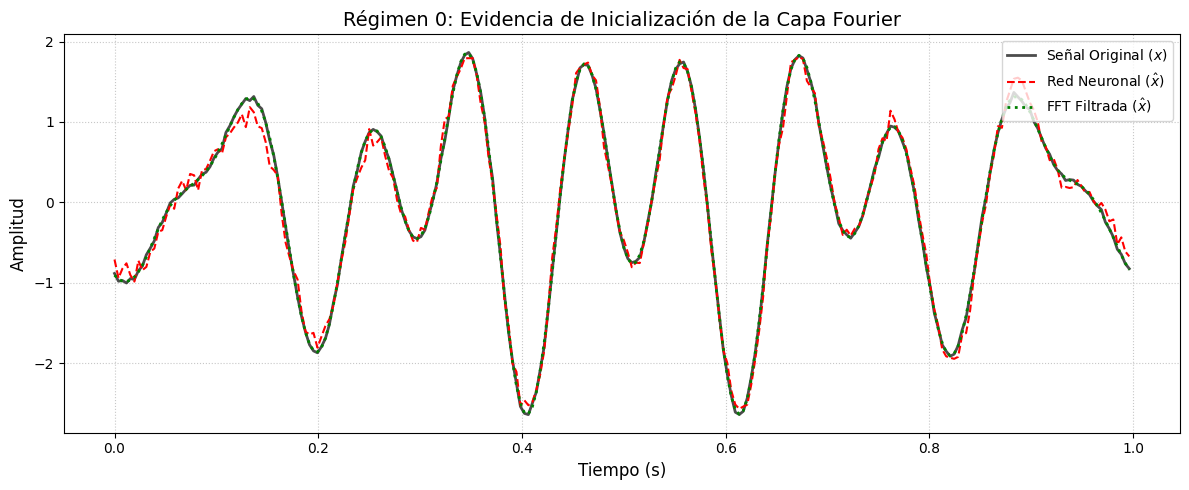

In [41]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Seleccionar una señal de ejemplo del régimen 0
sample_signal_idx = 0
original_signal = X_regimen_0[sample_signal_idx]

# 1. Reconstrucción con la red neuronal (inicialización Fourier)
# Aseguramos que pasamos un array de JAX con el formato de lote (1, 256)
x_input = jnp.expand_dims(jnp.array(original_signal), axis=0)
reconstructed_nn = predict(params_fourier_final, x_input)[0]

# 2. Reconstrucción utilizando FFT clásica
N = len(original_signal)
dt = t[1] - t[0]

# Calcular la FFT de la señal original
fft_original = np.fft.fft(original_signal)
frequencies = np.fft.fftfreq(N, d=float(dt))

# Crear un array para la FFT filtrada, inicializado a cero
filtered_fft = np.zeros_like(fft_original, dtype=complex)

# Extraer las frecuencias utilizadas en la construcción de W1
K_fourier = 30 # Definido en init_fourier
basis_freqs = np.arange(1, K_fourier + 1)

# Filtrar usando el índice más cercano (Nearest Bin) para evitar problemas de precisión
for freq in basis_freqs:
    # Índice de la frecuencia positiva
    idx_pos = np.argmin(np.abs(frequencies - freq))
    filtered_fft[idx_pos] = fft_original[idx_pos]

    # Índice de la frecuencia negativa conjugada
    idx_neg = np.argmin(np.abs(frequencies - (-freq)))
    filtered_fft[idx_neg] = fft_original[idx_neg]

# Realizar la IFFT para obtener la señal reconstruida
reconstructed_fft = np.fft.ifft(filtered_fft).real

# 3. Cálculo del Error de Reconstrucción Relativo |x_hat - x| / |x| (Norma L2)
norm_original = jnp.linalg.norm(original_signal)
rel_error_nn = jnp.linalg.norm(reconstructed_nn - original_signal) / norm_original
rel_error_fft = jnp.linalg.norm(reconstructed_fft - original_signal) / norm_original

print("Comparación de Error Relativo (Régimen 0)")
print("-" * 45)
print(f"-> Red Neuronal (Fourier): {float(rel_error_nn):.4f}")
print(f"-> FFT Filtrada (k=1..30): {float(rel_error_fft):.4f}")

# 4. Visualización Científica
plt.figure(figsize=(12, 5))
plt.plot(t, original_signal, label="Señal Original ($x$)", color='black', alpha=0.7, linewidth=2)
plt.plot(t, reconstructed_nn, label=r"Red Neuronal ($\hat{x}$)", color='red', linestyle='--', linewidth=1.5)
plt.plot(t, reconstructed_fft, label=r"FFT Filtrada ($\hat{x}$)", color='green', linestyle=':', linewidth=2)

plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.title("Régimen 0: Evidencia de Inicialización de la Capa Fourier", fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Reporte de Error de Reconstrucción Relativo |x_hat - x| / |x|
-----------------------------------------------------------------
Régimen 0:
  -> Error relativo (Fourier):   0.0936
  -> Error relativo (Aleatoria): 0.0878



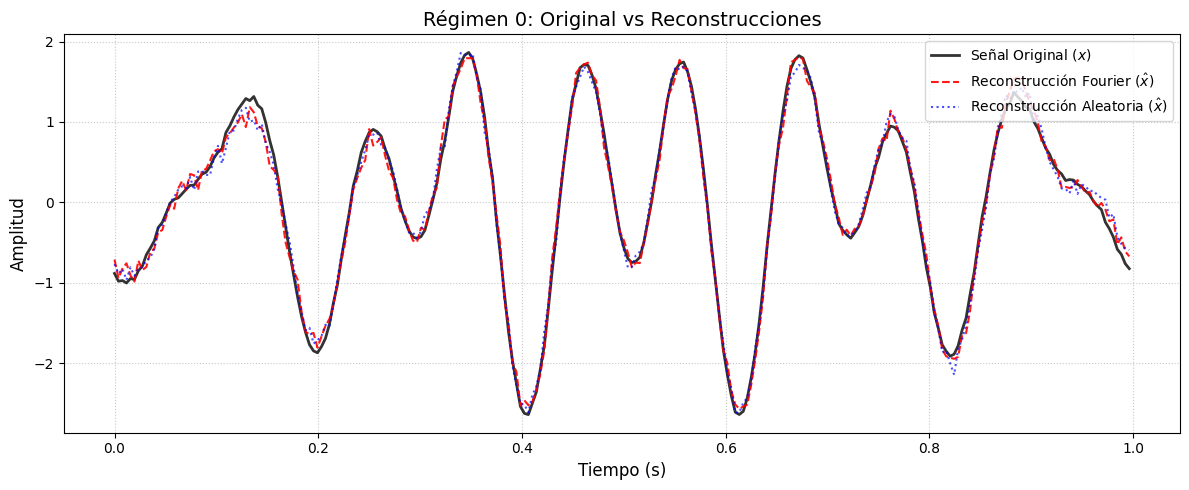

Régimen 1:
  -> Error relativo (Fourier):   0.1348
  -> Error relativo (Aleatoria): 0.1834



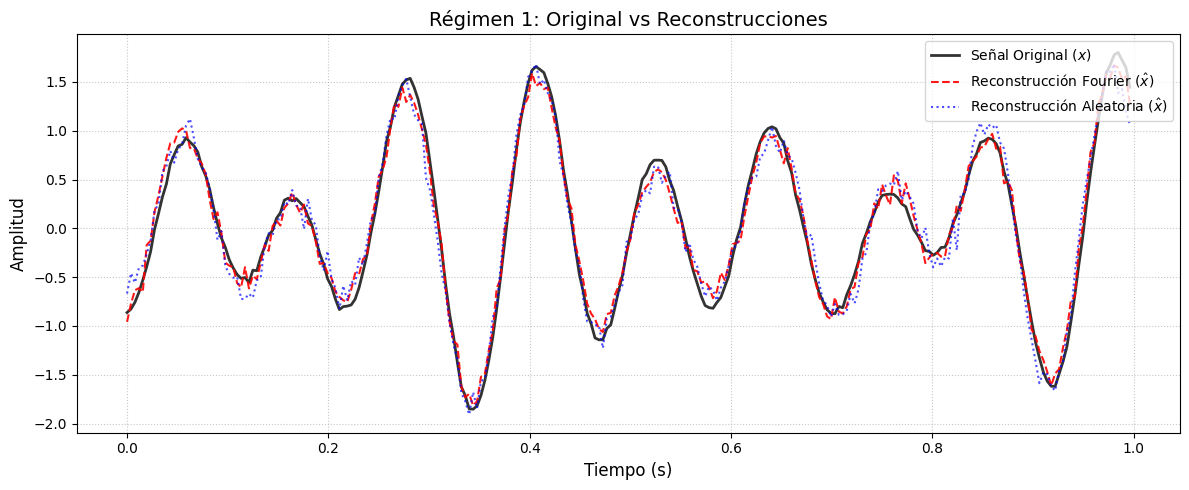

Régimen 2:
  -> Error relativo (Fourier):   0.1968
  -> Error relativo (Aleatoria): 0.1161



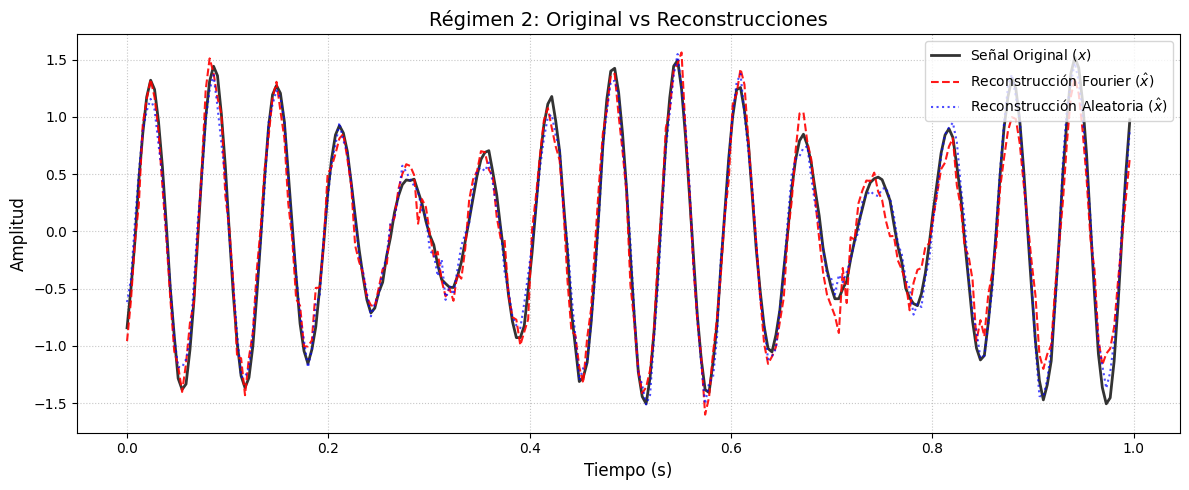

In [44]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Map trained parameters to their respective regimes
fourier_params_map = {
    0: params_fourier_final_r0,
    1: params_fourier_final_r1,
    2: params_fourier_final_r2,
}

random_params_map = {
    0: params_random_final_r0,
    1: params_random_final_r1,
    2: params_random_final_r2,
}

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

print("Reporte de Error de Reconstrucción Relativo |x_hat - x| / |x|")
print("-" * 65)

for regime in unique_regimes:
    # 1. Encontrar índices y extraer la primera señal de ejemplo
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        continue

    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Formato de lote (1, 256) para la función predict
    x_input = jnp.expand_dims(jnp.array(original_signal), axis=0)

    # Get regime-specific parameters
    current_fourier_params = fourier_params_map.get(regime)
    current_random_params = random_params_map.get(regime)

    # 2. Reconstrucción con ambas redes (requerido por la rúbrica)
    reconstructed_fourier = predict(current_fourier_params, x_input)[0]
    reconstructed_random = predict(current_random_params, x_input)[0]

    # 3. Cálculo del Error Relativo según la rúbrica: |x_hat - x| / |x|
    # Usamos la norma L2 (jnp.linalg.norm) que es la interpretación estándar para vectores
    error_relativo_fourier = jnp.linalg.norm(reconstructed_fourier - original_signal) / jnp.linalg.norm(original_signal)
    error_relativo_random = jnp.linalg.norm(reconstructed_random - original_signal) / jnp.linalg.norm(original_signal)

    print(f"Régimen {regime}:")
    print(f"  -> Error relativo (Fourier):   {float(error_relativo_fourier):.4f}")
    print(f"  -> Error relativo (Aleatoria): {float(error_relativo_random):.4f}\n")

    # 4. Gráfica: La señal original junto a su reconstrucción final (requerido por la rúbrica)
    plt.figure(figsize=(12, 5))

    # Se superponen las señales tal como pide la sección "Entrenamiento y reconstrucción"
    plt.plot(t, original_signal, label='Señal Original ($x$)', color='black', alpha=0.8, linewidth=2)
    # FIX: Changed '($\\hat{x}$)' to '($\hat{x}$)' to correctly use LaTeX math mode
    plt.plot(t, reconstructed_fourier, label=r'Reconstrucción Fourier ($\hat{x}$)', color='red', linestyle='--', alpha=0.9)
    plt.plot(t, reconstructed_random, label=r'Reconstrucción Aleatoria ($\hat{x}$)', color='blue', linestyle=':', alpha=0.7)

    plt.title(f'Régimen {regime}: Original vs Reconstrucciones', fontsize=14)
    plt.xlabel('Tiempo (s)', fontsize=12)
    plt.ylabel('Amplitud', fontsize=12)

    # Leyenda clara para visualización científica
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

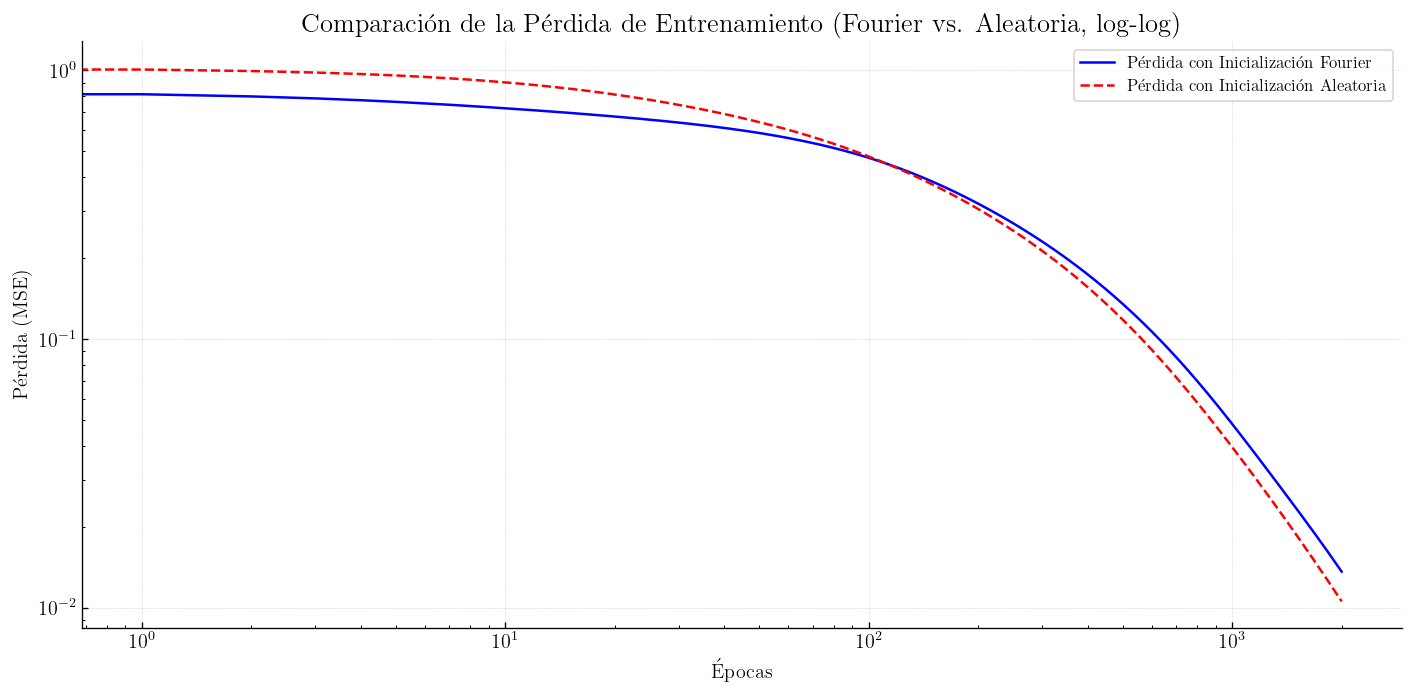

In [ ]:
#Fase n°4, comparacion de la perdida del error en el entrenamiento de las redes neuronales

import matplotlib.pyplot as plt

# Asegurarse de que las listas de pérdida sean arrays de JAX o NumPy para un ploteo fácil
loss_fourier_np = jnp.array(loss_fourier)
loss_random_np = jnp.array(loss_random)

# Crear la figura y los ejes para la gráfica
plt.figure(figsize=(12, 6))

# Graficar la pérdida con inicialización de Fourier
plt.loglog(loss_fourier_np, label='Pérdida con Inicialización Fourier', color='blue')

# Graficar la pérdida con inicialización Aleatoria
plt.loglog(loss_random_np, label='Pérdida con Inicialización Aleatoria', color='red', linestyle='--')

# Añadir título y etiquetas a los ejes
plt.title('Comparación de la Pérdida de Entrenamiento (Fourier vs. Aleatoria, log-log)', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)

# Añadir leyenda para identificar las líneas
plt.legend(fontsize=10)

# Añadir una cuadrícula para mejor legibilidad
plt.grid(True, linestyle=':', alpha=0.7)

# Ajustar el diseño para evitar recortes de etiquetas
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Función de Entrenamiento con Seguimiento del Error Relativo

Para poder medir la velocidad de convergencia en términos de error relativo, necesitamos una versión de la función de entrenamiento que, además de la pérdida, registre el error relativo máximo de la reconstrucción para una señal de ejemplo en cada época.

In [ ]:
def train_network_with_error_tracking(params, X_train, original_signal_for_error_calc, epochs=2000, lr=0.1):
    loss_history = []
    max_relative_error_history = []
    epsilon = 1e-8 # Pequeño valor para evitar la división por cero en el error relativo

    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        loss_history.append(loss)

        # Calcular la señal reconstruida para la señal original de ejemplo
        # La función 'predict' espera un lote, así que expandimos las dimensiones
        reconstructed_single_signal = predict(params, jnp.expand_dims(original_signal_for_error_calc, axis=0))[0]

        # Calcular el error relativo elemento a elemento
        relative_error = jnp.abs(reconstructed_single_signal - original_signal_for_error_calc) / (jnp.abs(original_signal_for_error_calc) + epsilon)

        # Almacenar el error relativo máximo para esta época
        max_relative_error_history.append(jnp.max(relative_error))

    return params, loss_history, max_relative_error_history

### Análisis de Convergencia para una Señal del Régimen 0

Calcularemos cuántas épocas necesita cada inicialización (Fourier y Aleatoria) para que el error relativo máximo de la reconstrucción de una señal de ejemplo (del Régimen 0) caiga por debajo de 0.1.

In [ ]:
# Seleccionar una señal de ejemplo del Régimen 0
sample_signal_regime0 = X_regimen_0[0]

# Generar nuevas claves para asegurar la reinicialización de los parámetros de la red
key_regime0_fourier, key_regime0_random = jax.random.split(jax.random.PRNGKey(5000))

# 1. Re-entrenar con inicialización Fourier y seguimiento del error para la señal de Régimen 0
params_fourier_init_regime0 = init_fourier(t, key_regime0_fourier)
_, _, max_relative_error_history_fourier_regime0 = \
    train_network_with_error_tracking(params_fourier_init_regime0, X_regimen_0, sample_signal_regime0)

# 2. Re-entrenar con inicialización Aleatoria y seguimiento del error para la señal de Régimen 0
params_random_init_regime0 = init_random(t, key_regime0_random)
_, _, max_relative_error_history_random_regime0 = \
    train_network_with_error_tracking(params_random_init_regime0, X_regimen_0, sample_signal_regime0)

# Encontrar el número de épocas para que el error relativo máximo sea menor a 0.1
epochs_fourier_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_fourier_regime0) if err < 0.1), -1)
epochs_random_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_random_regime0) if err < 0.1), -1)

print(f"Para una señal del Régimen 0 (Reconstrucción vs Original):")
print(f"  - Inicialización Fourier: {epochs_fourier_below_0_1} épocas para que el error relativo máximo baje de 0.1")
print(f"  - Inicialización Aleatoria: {epochs_random_below_0_1} épocas para que el error relativo máximo baje de 0.1")

Para una señal del Régimen 0 (Reconstrucción vs Original):
  - Inicialización Fourier: -1 épocas para que el error relativo máximo baje de 0.1
  - Inicialización Aleatoria: -1 épocas para que el error relativo máximo baje de 0.1


### Análisis de Convergencia para el Régimen Difícil

Basándonos en análisis previos, el Régimen 2 ha mostrado los errores relativos máximos más altos. A continuación, entrenaremos las redes nuevamente (usando los datos de entrenamiento del Régimen 0) pero monitoreando el error relativo de la reconstrucción para una señal específica del Régimen 2. Esto nos permitirá observar la velocidad de convergencia para un caso más desafiante.

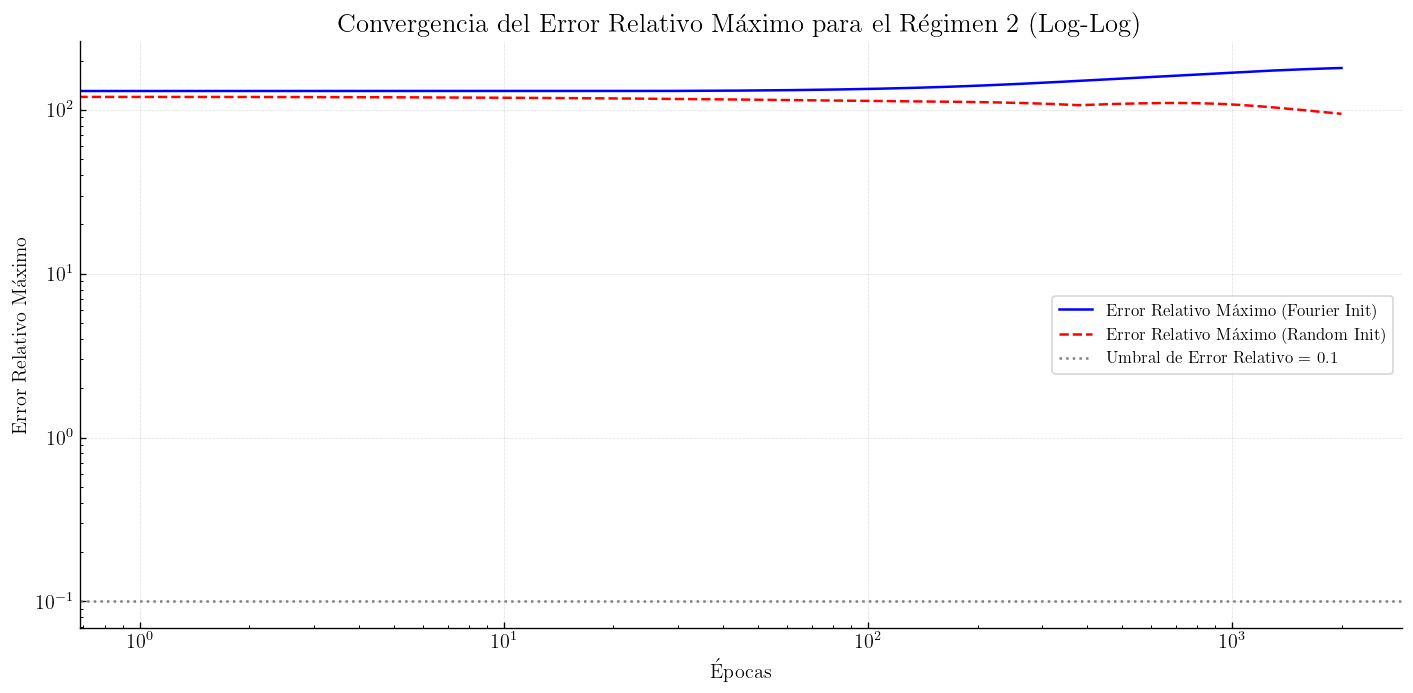

Para una señal del Régimen 2 (Reconstrucción vs Original) - (Régimen Difícil):
  - Inicialización Fourier: -1 épocas para que el error relativo máximo baje de 0.1
  - Inicialización Aleatoria: -1 épocas para que el error relativo máximo baje de 0.1


In [ ]:
# Identificar el régimen difícil (Régimen 2)
difficult_regime = 2
sample_signal_difficult = X[y == difficult_regime][0] # Tomar la primera señal del régimen 2

# Generar nuevas claves para la reinicialización de los parámetros de la red
key_difficult_fourier, key_difficult_random = jax.random.split(jax.random.PRNGKey(6000))

# 1. Re-entrenar con inicialización Fourier y seguimiento del error para la señal difícil
params_fourier_init_difficult = init_fourier(t, key_difficult_fourier)
_, _, max_relative_error_history_fourier_difficult = \
    train_network_with_error_tracking(params_fourier_init_difficult, X_regimen_0, sample_signal_difficult)

# 2. Re-entrenar con inicialización Aleatoria y seguimiento del error para la señal difícil
params_random_init_difficult = init_random(t, key_difficult_random)
_, _, max_relative_error_history_random_difficult = \
    train_network_with_error_tracking(params_random_init_difficult, X_regimen_0, sample_signal_difficult)

# Graficar el error relativo máximo vs. épocas para el régimen difícil
plt.figure(figsize=(12, 6))
plt.loglog(jnp.array(max_relative_error_history_fourier_difficult), label='Error Relativo Máximo (Fourier Init)', color='blue')
plt.loglog(jnp.array(max_relative_error_history_random_difficult), label='Error Relativo Máximo (Random Init)', color='red', linestyle='--')

plt.axhline(y=0.1, color='gray', linestyle=':', label='Umbral de Error Relativo = 0.1')

plt.title(f'Convergencia del Error Relativo Máximo para el Régimen {difficult_regime} (Log-Log)', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error Relativo Máximo', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Encontrar el número de épocas para que el error relativo máximo sea menor a 0.1 para el régimen difícil
epochs_fourier_difficult_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_fourier_difficult) if err < 0.1), -1)
epochs_random_difficult_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_random_difficult) if err < 0.1), -1)

print(f"Para una señal del Régimen {difficult_regime} (Reconstrucción vs Original) - (Régimen Difícil):")
print(f"  - Inicialización Fourier: {epochs_fourier_difficult_below_0_1} épocas para que el error relativo máximo baje de 0.1")
print(f"  - Inicialización Aleatoria: {epochs_random_difficult_below_0_1} épocas para que el error relativo máximo baje de 0.1")